In [1]:
import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from ultralytics import YOLO

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

ROOT = Path.cwd()
DATASET_DIR = ROOT / "dataset"
YOLO_WEIGHTS = ROOT / "best.pt"
LABELS_FILE = ROOT / "4_1_features_transformation_and_merging.xlsx"
OUTPUT_DIR = ROOT / "vit_person_output"
PERSON_CROPS_DIR = ROOT / "crops" / "person_crops"
FACE_CROPS_DIR = ROOT / "crops" / "face_crops"
HEAD_CROPS_DIR = ROOT / "crops" / "head_crops"
PROGRESS_DIR = OUTPUT_DIR / "progress_json"
BACKBONE = "vit_l_16"
EPOCHS = 5
BATCH_SIZE = 16
LR = 1e-4
IMG_SIZE = 224
TEST_SIZE = 0.1
VAL_SIZE = 0.1
SEED = 42
YOLO_CONF = 0.25
YOLO_IMGSZ = 640
REUSE_EXISTING_CROPS = False
CROP_STAGE_MODE = "auto"
ALLOW_YOLO_AUTOFILL = True
VAL_COMPUTE_PER_FEATURE_F1 = False
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

preview_df = pd.read_excel(LABELS_FILE)
print({"rows": int(preview_df.shape[0]), "cols": int(preview_df.shape[1])})
preview_df.head()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PERSON_CROPS_DIR.mkdir(parents=True, exist_ok=True)
FACE_CROPS_DIR.mkdir(parents=True, exist_ok=True)
HEAD_CROPS_DIR.mkdir(parents=True, exist_ok=True)
PROGRESS_DIR.mkdir(parents=True, exist_ok=True)
(PROGRESS_DIR / "epochs").mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Не найдена папка датасета: {DATASET_DIR}")
if not YOLO_WEIGHTS.exists():
    raise FileNotFoundError(f"Не найден файл весов YOLO: {YOLO_WEIGHTS}")
if not LABELS_FILE.exists():
    raise FileNotFoundError(f"Не найден файл с признаками: {LABELS_FILE}")

torch.manual_seed(SEED)
np.random.seed(SEED)


{'rows': 8422, 'cols': 147}


In [2]:
def read_labels_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls", ".xlsm"}:
        return pd.read_excel(path)
    if suffix in {".csv", ".txt"}:
        return pd.read_csv(path)
    raise ValueError(f"Неподдерживаемый формат файла: {path}")


def find_image_column(df: pd.DataFrame) -> str:
    lower_to_orig = {str(c).lower(): str(c) for c in df.columns}
    candidates = ["image", "image_name", "filename", "file", "img", "image_id", "name", "path"]
    for c in candidates:
        if c in lower_to_orig:
            return lower_to_orig[c]
    for col in df.columns:
        s = df[col].astype(str).str.lower()
        if s.str.contains(".png", regex=False).any() or s.str.contains(".jpg", regex=False).any() or s.str.contains(".jpeg", regex=False).any():
            return str(col)
    raise ValueError("Не удалось найти колонку с изображением")


def select_target_columns(df: pd.DataFrame, image_col: str) -> list[str]:
    blocked_exact = {image_col.lower(), "split", "subset", "set"}
    blocked_partials = ["идентификатор", "identifier", "image", "img", "file", "filename", "path"]
    out = []
    for c in df.columns:
        cl = str(c).lower().strip()
        if cl in blocked_exact:
            continue
        if any(p in cl for p in blocked_partials):
            continue
        out.append(str(c))
    if not out:
        raise ValueError("Не удалось найти целевые признаки")
    return out


def normalize_value(v):
    if pd.isna(v):
        return "__MISSING__"
    s = str(v).strip()
    if not s:
        return "__MISSING__"
    if s.lower() in {"nan", "none", "null"}:
        return "__MISSING__"
    return s


def infer_feature_type(labels):
    return "binary" if len(labels) <= 2 else "multiclass"


all_png = sorted(p for p in DATASET_DIR.rglob("*") if p.is_file() and p.suffix.lower() == ".png")
by_name = {p.name: p for p in all_png}
by_stem = {}
for p in all_png:
    if p.stem not in by_stem:
        by_stem[p.stem] = p


def resolve_image_path(value: str) -> Path | None:
    v = str(value).strip()
    if not v:
        return None
    p = Path(v)
    if p.exists() and p.is_file():
        return p
    name = Path(v).name
    if name in by_name:
        return by_name[name]
    stem = Path(name).stem
    if stem in by_stem:
        return by_stem[stem]
    return None


from feature_lists import full_image_person_features

df = read_labels_table(LABELS_FILE)
image_col = find_image_column(df)
all_candidate_target_cols = select_target_columns(df, image_col)
allowed_feature_set = set(full_image_person_features)
target_cols = [c for c in all_candidate_target_cols if c in allowed_feature_set]

if not target_cols:
    raise ValueError("Для person-crop модели не найдено признаков из списка full_image_person_features")

print(
    f"Для person-crop обучения выбрано признаков из списка: {len(target_cols)} "
    f"(кандидатов до фильтрации: {len(all_candidate_target_cols)})"
)

df = df.dropna(subset=[image_col]).copy()
df["resolved_image"] = df[image_col].apply(resolve_image_path)
df = df[df["resolved_image"].notnull()].copy()

feature_infos_all = {}
for c in target_cols:
    vals = df[c].map(normalize_value)
    labels = sorted(vals.unique().tolist())
    if "__MISSING__" in labels:
        labels = ["__MISSING__"] + [x for x in labels if x != "__MISSING__"]
    label2id = {k: i for i, k in enumerate(labels)}
    id2label = {str(i): k for i, k in enumerate(labels)}
    counts = vals.value_counts(dropna=False).to_dict()
    missing_count = int(counts.get("__MISSING__", 0))
    feature_type = infer_feature_type(labels)
    feature_infos_all[c] = {
        "feature_type": feature_type,
        "num_labels": int(len(labels)),
        "label2id": label2id,
        "id2label": id2label,
        "counts": {str(k): int(v) for k, v in counts.items()},
        "has_missing": "__MISSING__" in label2id,
        "missing_count": missing_count,
    }
    print(
        f"Признак '{c}': тип={feature_type}, классов={len(labels)}, "
        f"есть_пропуски={'да' if '__MISSING__' in label2id else 'нет'}, "
        f"пропусков={missing_count}"
    )

target_cols = [c for c in target_cols if int(feature_infos_all[c]["num_labels"]) >= 2]
excluded_single_label = [c for c, v in feature_infos_all.items() if int(v["num_labels"]) < 2]
feature_infos = {c: feature_infos_all[c] for c in target_cols}
print(
    f"Признаков всего: {len(feature_infos_all)} | "
    f"исключено одно-классовых: {len(excluded_single_label)} | "
    f"итоговых признаков: {len(target_cols)}"
)


def encode_row(row):
    return [int(feature_infos[c]["label2id"][normalize_value(row[c])]) for c in target_cols]


df["encoded_targets"] = df.apply(encode_row, axis=1)

if len(df) < 10:
    raise ValueError("Слишком мало подходящих примеров после сопоставления")

train_df, temp_df = train_test_split(df, test_size=VAL_SIZE + TEST_SIZE, random_state=SEED, shuffle=True)
val_ratio_in_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
val_df, test_df = train_test_split(temp_df, test_size=1 - val_ratio_in_temp, random_state=SEED, shuffle=True)

feature_class_counts = [int(feature_infos[c]["num_labels"]) for c in target_cols]

feature_schema = {
    "image_column": image_col,
    "target_count": int(len(target_cols)),
    "targets": target_cols,
    "feature_class_counts": feature_class_counts,
    "excluded_single_label_count": int(len(excluded_single_label)),
    "excluded_single_label_features": excluded_single_label,
    "features": feature_infos,
}
with (PROGRESS_DIR / "feature_schema.json").open("w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

split_stats = {
    "total": int(len(df)),
    "train": int(len(train_df)),
    "val": int(len(val_df)),
    "test": int(len(test_df)),
    "targets_count": int(len(target_cols)),
    "targets": target_cols,
}
with (PROGRESS_DIR / "split_stats.json").open("w", encoding="utf-8") as f:
    json.dump(split_stats, f, ensure_ascii=False, indent=2)
split_stats


Для person-crop обучения выбрано признаков из списка: 115 (кандидатов до фильтрации: 146)
Признак ''Кусочные', степень выраженности': тип=multiclass, классов=4, есть_пропуски=да, пропусков=5974
Признак ''Промахивающиеся', степень выраженности': тип=multiclass, классов=4, есть_пропуски=да, пропусков=5295
Признак 'Аккуратность рисунка': тип=multiclass, классов=3, есть_пропуски=нет, пропусков=0
Признак 'Аккуратность штриховки (низкая)': тип=binary, классов=2, есть_пропуски=да, пропусков=6468
Признак 'Аккуратность штриховки (средняя (стандарт))': тип=binary, классов=2, есть_пропуски=да, пропусков=6089
Признак 'Волосы или шапка (аккуратность)': тип=multiclass, классов=3, есть_пропуски=да, пропусков=4619
Признак 'Волосы или шапка (без особенностей)': тип=binary, классов=2, есть_пропуски=да, пропусков=3898
Признак 'Голова (без особенностей)': тип=binary, классов=2, есть_пропуски=да, пропусков=2188
Признак 'Голова (искажена форма)': тип=binary, классов=2, есть_пропуски=да, пропусков=6973
Призн

{'total': 7392,
 'train': 5913,
 'val': 739,
 'test': 740,
 'targets_count': 115,
 'targets': ["'Кусочные', степень выраженности",
  "'Промахивающиеся', степень выраженности",
  'Аккуратность рисунка',
  'Аккуратность штриховки (низкая)',
  'Аккуратность штриховки (средняя (стандарт))',
  'Волосы или шапка (аккуратность)',
  'Волосы или шапка (без особенностей)',
  'Голова (без особенностей)',
  'Голова (искажена форма)',
  'Голова (размер)',
  'Грубые нарушения рисунка (нарушение пропорций)',
  'Грубые нарушения рисунка (отклонение от вертикали)',
  'Грубые нарушения рисунка (отсутствуют)',
  'Два глаза одинаковые',
  'Детали (лицо) (волосы (шапка))',
  'Детали (лицо) (глаза (один или оба))',
  'Детали (лицо) (другое)',
  'Детали (лицо) (лоб)',
  'Детали (лицо) (нос)',
  'Детали (лицо) (рот)',
  'Детали (лицо) (уши)',
  'Детализированность',
  'Дополнительно (в руке или рядом) (дополнительные предметы отсутствуют)',
  'Дополнительные детали изображения фигуры (другое)',
  'Дополнитель

In [3]:
def valid_crop(path: Path) -> bool:
    return path.exists() and path.stat().st_size > 0


def resolve_existing_person_crop(person_dir: Path, src_stem: str, idx: int):
    exact = person_dir / f"{src_stem}_{idx}.png"
    if valid_crop(exact):
        return exact
    plain = person_dir / f"{src_stem}.png"
    if valid_crop(plain):
        return plain
    matches = sorted(person_dir.glob(f"{src_stem}_*.png"))
    for m in matches:
        if valid_crop(m):
            return m
    return None


def split_crop_status(split_name: str, split_df: pd.DataFrame):
    person_dir = PERSON_CROPS_DIR / split_name
    person_dir.mkdir(parents=True, exist_ok=True)
    total = int(len(split_df))
    missing_person = 0
    for i, row in split_df.reset_index(drop=True).iterrows():
        src = Path(row["resolved_image"])
        existing = resolve_existing_person_crop(person_dir, src.stem, i)
        if existing is None:
            missing_person += 1
    return {
        "split": split_name,
        "total": total,
        "missing_person": missing_person,
    }


status_before = {
    "train": split_crop_status("train", train_df),
    "val": split_crop_status("val", val_df),
    "test": split_crop_status("test", test_df),
}
print(f"Режим этапа кропов: {CROP_STAGE_MODE}")
print(f"Состояние train: {status_before['train']}")
print(f"Состояние val: {status_before['val']}")
print(f"Состояние test: {status_before['test']}")

need_yolo = any(v["missing_person"] > 0 for v in status_before.values())


def should_use_yolo(need_yolo: bool, stage_mode: str, allow_autofill: bool) -> bool:
    if stage_mode == "always":
        return True
    if stage_mode == "never":
        return False
    return bool(need_yolo and allow_autofill)


use_yolo = should_use_yolo(need_yolo, CROP_STAGE_MODE, ALLOW_YOLO_AUTOFILL)

if need_yolo and not use_yolo:
    print("Этап YOLO отключен: есть недостающие кропы, но автодозаполнение выключено")
else:
    stage_text = "включен" if use_yolo else "пропущен"
    print(f"Этап YOLO: {stage_text}; требуется YOLO: {'да' if need_yolo else 'нет'}")

if use_yolo:
    yolo_model = YOLO(str(YOLO_WEIGHTS))
    names = yolo_model.names if hasattr(yolo_model, "names") else {}
else:
    yolo_model = None
    names = {}


def get_class_id(target_name: str, fallback: int) -> int:
    if isinstance(names, dict):
        for k, v in names.items():
            if str(v).strip().lower() == target_name:
                return int(k)
    return fallback


person_class_id = get_class_id("персонаж", 2)


def crop_best_class(src_path: Path, dst_path: Path, class_id: int):
    idx = int(dst_path.stem.rsplit("_", 1)[-1]) if "_" in dst_path.stem and dst_path.stem.rsplit("_", 1)[-1].isdigit() else -1
    existing = resolve_existing_person_crop(dst_path.parent, src_path.stem, idx)
    if existing is not None:
        return "reused", existing
    if yolo_model is None:
        return "missing", None
    results = yolo_model.predict(source=str(src_path), conf=YOLO_CONF, imgsz=YOLO_IMGSZ, classes=[class_id], device=DEVICE, verbose=False)
    if not results:
        return "missing", None
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return "missing", None
    conf = boxes.conf.detach().cpu().numpy()
    best_idx = int(np.argmax(conf))
    xyxy = boxes.xyxy[best_idx].detach().cpu().numpy().tolist()
    x1, y1, x2, y2 = [int(v) for v in xyxy]
    with Image.open(src_path).convert("RGB") as img:
        w, h = img.size
        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(x1 + 1, min(x2, w))
        y2 = max(y1 + 1, min(y2, h))
        crop = img.crop((x1, y1, x2, y2))
        crop.save(dst_path)
    return "created", dst_path


def build_split_records(split_name: str, split_df: pd.DataFrame):
    person_dir = PERSON_CROPS_DIR / split_name
    person_dir.mkdir(parents=True, exist_ok=True)
    records = []
    dropped_person = 0
    reused_person = 0
    created_person = 0
    total_items = int(len(split_df))
    for i, row in split_df.reset_index(drop=True).iterrows():
        src = Path(row["resolved_image"])
        person_dst = person_dir / f"{src.stem}_{i}.png"
        person_status, person_path = crop_best_class(src, person_dst, person_class_id)
        if person_status == "reused":
            reused_person += 1
        if person_status == "created":
            created_person += 1
        if person_status == "missing":
            dropped_person += 1
        else:
            records.append({"image": str(person_path), "target": [int(v) for v in row["encoded_targets"]]})
        processed = i + 1
        if processed % 100 == 0 or processed == total_items:
            print(
                f"Сплит '{split_name}': обработано {processed}/{total_items}, "
                f"сохранено={len(records)}, переиспользовано={reused_person}, "
                f"создано={created_person}, пропущено={dropped_person}"
            )
    report = {
        "split": split_name,
        "kept_person_for_training": len(records),
        "dropped_person": dropped_person,
        "reused_person": reused_person,
        "created_person": created_person,
        "reuse_existing_crops": REUSE_EXISTING_CROPS,
        "crop_stage_mode": CROP_STAGE_MODE,
        "used_yolo": bool(use_yolo),
    }
    with (PROGRESS_DIR / f"crop_report_{split_name}.json").open("w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)
    with (OUTPUT_DIR / f"{split_name}_records.json").open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)
    return records, report


train_records, train_report = build_split_records("train", train_df)
val_records, val_report = build_split_records("val", val_df)
test_records, test_report = build_split_records("test", test_df)

if len(train_records) == 0 or len(val_records) == 0 or len(test_records) == 0:
    raise ValueError("После подготовки кропов персонажа один из сплитов оказался пустым")

{"train": train_report, "val": val_report, "test": test_report, "used_yolo": bool(use_yolo)}


Режим этапа кропов: auto
Состояние train: {'split': 'train', 'total': 5913, 'missing_person': 1}
Состояние val: {'split': 'val', 'total': 739, 'missing_person': 0}
Состояние test: {'split': 'test', 'total': 740, 'missing_person': 0}
Этап YOLO: включен; требуется YOLO: да
Сплит 'train': обработано 100/5913, сохранено=100, переиспользовано=100, создано=0, пропущено=0
Сплит 'train': обработано 200/5913, сохранено=200, переиспользовано=200, создано=0, пропущено=0
Сплит 'train': обработано 300/5913, сохранено=300, переиспользовано=300, создано=0, пропущено=0
Сплит 'train': обработано 400/5913, сохранено=400, переиспользовано=400, создано=0, пропущено=0
Сплит 'train': обработано 500/5913, сохранено=500, переиспользовано=500, создано=0, пропущено=0
Сплит 'train': обработано 600/5913, сохранено=600, переиспользовано=600, создано=0, пропущено=0
Сплит 'train': обработано 700/5913, сохранено=700, переиспользовано=700, создано=0, пропущено=0
Сплит 'train': обработано 800/5913, сохранено=800, переи

{'train': {'split': 'train',
  'kept_person_for_training': 5912,
  'dropped_person': 1,
  'reused_person': 5912,
  'created_person': 0,
  'reuse_existing_crops': False,
  'crop_stage_mode': 'auto',
  'used_yolo': True},
 'val': {'split': 'val',
  'kept_person_for_training': 739,
  'dropped_person': 0,
  'reused_person': 739,
  'created_person': 0,
  'reuse_existing_crops': False,
  'crop_stage_mode': 'auto',
  'used_yolo': True},
 'test': {'split': 'test',
  'kept_person_for_training': 740,
  'dropped_person': 0,
  'reused_person': 740,
  'created_person': 0,
  'reuse_existing_crops': False,
  'crop_stage_mode': 'auto',
  'used_yolo': True},
 'used_yolo': True}

In [4]:
class MultiTaskImageDataset(Dataset):
    def __init__(self, records, transform, split_name):
        self.records = [r for r in records if Path(r["image"]).exists()]
        self.transform = transform
        dropped = int(len(records) - len(self.records))
        if dropped > 0:
            print(f"Сплит '{split_name}': пропущено отсутствующих файлов={dropped}, оставлено={len(self.records)}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["image"]).convert("RGB")
        x = self.transform(img)
        y = torch.tensor(rec["target"], dtype=torch.long)
        return x, y


class ViTMultiHead(nn.Module):
    def __init__(self, class_counts, backbone_name):
        super().__init__()
        if backbone_name == "vit_l_16":
            backbone = models.vit_l_16(weights=models.ViT_L_16_Weights.DEFAULT)
        elif backbone_name == "vit_b_16":
            backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        elif backbone_name == "vit_b_32":
            backbone = models.vit_b_32(weights=models.ViT_B_32_Weights.DEFAULT)
        else:
            raise ValueError(f"Неподдерживаемая архитектура backbone: {backbone_name}")
        in_features = backbone.heads.head.in_features
        backbone.heads.head = nn.Identity()
        self.backbone = backbone
        self.heads = nn.ModuleList([nn.Linear(in_features, int(c)) for c in class_counts])

    def forward(self, x):
        feat = self.backbone(x)
        return [head(feat) for head in self.heads]


train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = MultiTaskImageDataset(train_records, train_tf, "train")
val_ds = MultiTaskImageDataset(val_records, eval_tf, "val")
test_ds = MultiTaskImageDataset(test_records, eval_tf, "test")
if len(train_ds) == 0 or len(val_ds) == 0 or len(test_ds) == 0:
    raise ValueError(
        f"Пустой датасет после подготовки: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}"
    )

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = ViTMultiHead(feature_class_counts, BACKBONE).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [5]:
def epoch_pass(loader, model, optimizer=None, epoch=0, mode="train"):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss = 0.0
    total_count = 0
    acc_sum = 0.0
    pbar = tqdm(loader, desc=f"{mode} {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits_list = model(x)
        losses = []
        pred_list = []
        for i, logits in enumerate(logits_list):
            yi = y[:, i]
            losses.append(nn.functional.cross_entropy(logits, yi))
            pred_list.append(logits.argmax(dim=1))
        loss = torch.stack(losses).mean()
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        with torch.no_grad():
            per_feature_acc = torch.stack([(pred_list[i] == y[:, i]).float().mean() for i in range(len(pred_list))])
            batch_acc = per_feature_acc.mean().item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{batch_acc:.4f}"})
        bsz = x.size(0)
        total_loss += loss.item() * bsz
        acc_sum += batch_acc * bsz
        total_count += bsz
    return total_loss / total_count, acc_sum / total_count


def evaluate_f1(loader, model, per_feature=False):
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits_list = model(x)
            preds = torch.stack([logits.argmax(dim=1) for logits in logits_list], dim=1).cpu().numpy().astype(np.int32)
            all_pred.append(preds)
            all_true.append(y.numpy().astype(np.int32))
    y_true = np.vstack(all_true)
    y_pred = np.vstack(all_pred)
    flat_true = y_true.reshape(-1)
    flat_pred = y_pred.reshape(-1)
    out = {
        "f1_micro": float(f1_score(flat_true, flat_pred, average="micro", zero_division=0)),
        "f1_macro": float(f1_score(flat_true, flat_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(flat_true, flat_pred, average="weighted", zero_division=0)),
    }
    if per_feature:
        out["f1_per_feature_macro"] = {
            k: float(f1_score(y_true[:, i], y_pred[:, i], average="macro", zero_division=0))
            for i, k in enumerate(target_cols)
        }
    return out


history = []
for epoch in tqdm(range(1, EPOCHS + 1), desc="epochs"):
    t0 = time.time()
    train_loss, train_acc = epoch_pass(train_loader, model, optimizer, epoch=epoch, mode="train")
    val_loss, val_acc = epoch_pass(val_loader, model, optimizer=None, epoch=epoch, mode="val")
    val_f1 = evaluate_f1(val_loader, model, per_feature=VAL_COMPUTE_PER_FEATURE_F1)
    rec = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "val_loss": float(val_loss),
        "val_accuracy": float(val_acc),
        "val_f1_micro": float(val_f1["f1_micro"]),
        "val_f1_macro": float(val_f1["f1_macro"]),
        "val_f1_weighted": float(val_f1["f1_weighted"]),
        "seconds": float(time.time() - t0),
    }
    if VAL_COMPUTE_PER_FEATURE_F1:
        rec["val_f1_per_feature_macro"] = val_f1["f1_per_feature_macro"]
    history.append(rec)
    print(
        f"Эпоха {epoch}: train_loss={rec['train_loss']:.4f}, val_loss={rec['val_loss']:.4f}, "
        f"train_acc={rec['train_accuracy']:.4f}, val_acc={rec['val_accuracy']:.4f}, "
        f"val_f1_macro={rec['val_f1_macro']:.4f}, время={rec['seconds']:.1f}с"
    )
    with (PROGRESS_DIR / "epochs" / f"epoch_{epoch:03d}.json").open("w", encoding="utf-8") as f:
        json.dump(rec, f, ensure_ascii=False, indent=2)
    with (PROGRESS_DIR / "history.json").open("w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

torch.save({
    "backbone": BACKBONE,
    "model_state_dict": model.state_dict(),
    "target_cols": target_cols,
    "feature_class_counts": feature_class_counts,
    "feature_infos": feature_infos,
}, OUTPUT_DIR / "vit_person_multitask.pth")
history_df = pd.DataFrame(history)
history_df


epochs:   0%|          | 0/5 [00:00<?, ?it/s]

train 1/5:   0%|          | 0/370 [00:00<?, ?it/s]

val 1/5:   0%|          | 0/47 [00:00<?, ?it/s]

Эпоха 1: train_loss=0.4324, val_loss=0.4030, train_acc=0.8237, val_acc=0.8365, val_f1_macro=0.7027, время=896.5с


train 2/5:   0%|          | 0/370 [00:00<?, ?it/s]

...

Эпоха 4: train_loss=0.2963, val_loss=0.3670, train_acc=0.8804, val_acc=0.8520, val_f1_macro=0.7569, время=884.4с


train 5/5:   0%|          | 0/370 [00:00<?, ?it/s]

val 5/5:   0%|          | 0/47 [00:00<?, ?it/s]

Эпоха 5: train_loss=0.2488, val_loss=0.3848, train_acc=0.9016, val_acc=0.8520, val_f1_macro=0.7445, время=883.3с


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_f1_micro,val_f1_macro,val_f1_weighted,seconds
0,1,0.432403,0.823679,0.402972,0.836536,0.836536,0.702691,0.832949,896.520682
1,2,0.372463,0.849054,0.372206,0.849056,0.849056,0.739539,0.845524,903.772939
2,3,0.336197,0.863692,0.369120,0.851327,0.851327,0.748954,0.848629,899.439726
3,4,0.296309,0.880439,0.366976,0.851986,0.851986,0.756885,0.849879,884.409064
4,5,0.248753,0.901619,0.384793,0.851950,0.851950,0.744548,0.849109,883.286042


'E:\\SosedTemporary\\WorkingSpace\\Narabotki\\26-05-18_1\\vit_person_output\\training_curves.png'

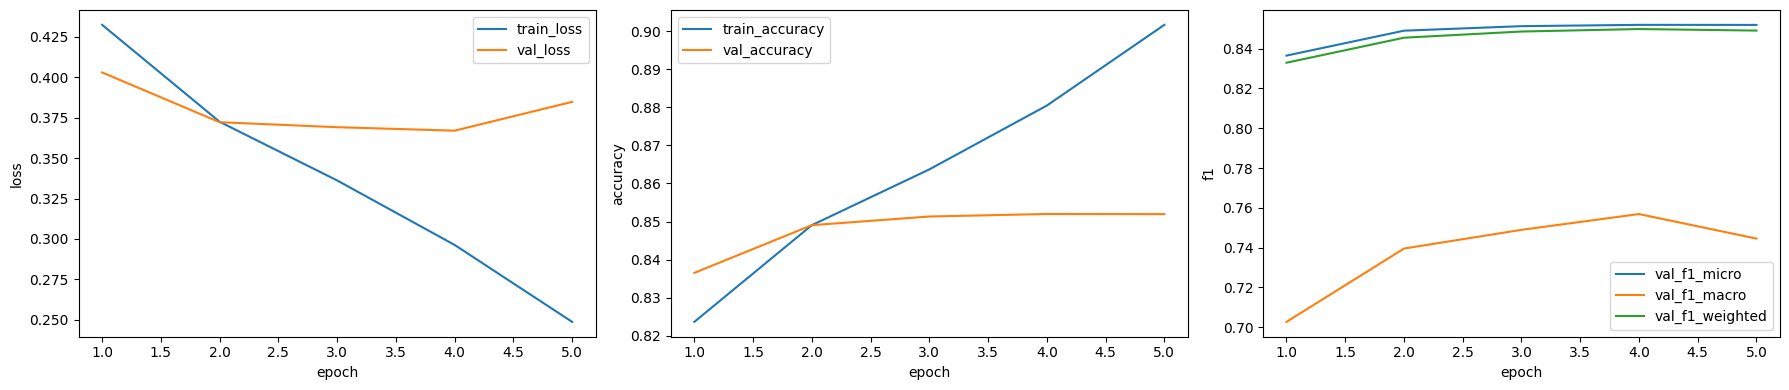

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

f1_metrics = ["val_f1_micro", "val_f1_macro", "val_f1_weighted"]
for metric_name in f1_metrics:
    if metric_name in history_df.columns:
        axes[2].plot(history_df["epoch"], history_df[metric_name], label=metric_name)
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("f1")
axes[2].legend()

plot_path = OUTPUT_DIR / "training_curves.png"
fig.tight_layout()
fig.savefig(plot_path, dpi=150)
str(plot_path.resolve())


In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import f1_score

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "vit_person_output"
CKPT_PATH = OUTPUT_DIR / "vit_person_multitask.pth"
TEST_RECORDS_PATH = OUTPUT_DIR / "test_records.json"
BATCH_SIZE = 16
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not CKPT_PATH.exists():
    raise FileNotFoundError(f"Не найден файл чекпоинта: {CKPT_PATH}")
if not TEST_RECORDS_PATH.exists():
    raise FileNotFoundError(f"Не найден файл тестовых записей: {TEST_RECORDS_PATH}")

ckpt = torch.load(CKPT_PATH, map_location="cpu")
target_cols = ckpt["target_cols"]
feature_class_counts = ckpt["feature_class_counts"]

backbone_name = ckpt.get("backbone", "vit_l_16")

class ViTMultiHead(nn.Module):
    def __init__(self, class_counts, backbone_name):
        super().__init__()
        if backbone_name == "vit_l_16":
            backbone = models.vit_l_16(weights=None)
        elif backbone_name == "vit_b_16":
            backbone = models.vit_b_16(weights=None)
        elif backbone_name == "vit_b_32":
            backbone = models.vit_b_32(weights=None)
        else:
            raise ValueError(f"Неподдерживаемая архитектура backbone: {backbone_name}")
        in_features = backbone.heads.head.in_features
        backbone.heads.head = nn.Identity()
        self.backbone = backbone
        self.heads = nn.ModuleList([nn.Linear(in_features, int(c)) for c in class_counts])

    def forward(self, x):
        feat = self.backbone(x)
        return [head(feat) for head in self.heads]

model = ViTMultiHead(feature_class_counts, backbone_name)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE)
model.eval()

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

records = json.loads(TEST_RECORDS_PATH.read_text(encoding="utf-8"))
records = [r for r in records if Path(r["image"]).exists()]
if len(records) == 0:
    raise ValueError("Не найдено доступных тестовых записей")

class MultiTaskImageDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["image"]).convert("RGB")
        x = self.transform(img)
        y = torch.tensor(rec["target"], dtype=torch.long)
        return x, y

test_ds = MultiTaskImageDataset(records, eval_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_true = []
all_pred = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits_list = model(x)
        preds = torch.stack([logits.argmax(dim=1) for logits in logits_list], dim=1).cpu().numpy().astype(np.int32)
        all_pred.append(preds)
        all_true.append(y.numpy().astype(np.int32))

y_true = np.vstack(all_true)
y_pred = np.vstack(all_pred)

flat_true = y_true.reshape(-1)
flat_pred = y_pred.reshape(-1)
f1_micro = f1_score(flat_true, flat_pred, average="micro", zero_division=0)
f1_macro = f1_score(flat_true, flat_pred, average="macro", zero_division=0)
f1_weighted = f1_score(flat_true, flat_pred, average="weighted", zero_division=0)

f1_per_feature_micro = [f1_score(y_true[:, i], y_pred[:, i], average="micro", zero_division=0) for i in range(y_true.shape[1])]
f1_per_feature_macro = [f1_score(y_true[:, i], y_pred[:, i], average="macro", zero_division=0) for i in range(y_true.shape[1])]
f1_per_feature_weighted = [f1_score(y_true[:, i], y_pred[:, i], average="weighted", zero_division=0) for i in range(y_true.shape[1])]

summary_df = pd.DataFrame([
    {"metric": "f1_micro", "value": float(f1_micro)},
    {"metric": "f1_macro", "value": float(f1_macro)},
    {"metric": "f1_weighted", "value": float(f1_weighted)},
])
per_feature_df = pd.DataFrame({
    "feature": target_cols,
    "num_labels": feature_class_counts,
    "f1_micro": f1_per_feature_micro,
    "f1_macro": f1_per_feature_macro,
    "f1_weighted": f1_per_feature_weighted,
})

xlsx_path = OUTPUT_DIR / "test_f1_metrics.xlsx"
with pd.ExcelWriter(xlsx_path) as writer:
    summary_df.to_excel(writer, index=False, sheet_name="summary")
    per_feature_df.to_excel(writer, index=False, sheet_name="per_feature")

f1_json = {
    "f1_micro": float(f1_micro),
    "f1_macro": float(f1_macro),
    "f1_weighted": float(f1_weighted),
    "per_feature_f1_micro": {k: float(v) for k, v in zip(target_cols, f1_per_feature_micro)},
    "per_feature_f1_macro": {k: float(v) for k, v in zip(target_cols, f1_per_feature_macro)},
    "per_feature_f1_weighted": {k: float(v) for k, v in zip(target_cols, f1_per_feature_weighted)},
}
with (OUTPUT_DIR / "test_f1_metrics.json").open("w", encoding="utf-8") as f:
    json.dump(f1_json, f, ensure_ascii=False, indent=2)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from IPython.display import display

pd.set_option("display.colheader_justify", "left")

def _left(df):
    return df.style.set_properties(**{"text-align": "left"}).set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
    ])

display(_left(summary_df))
display(_left(per_feature_df))



,metric,value
0,f1_micro,0.852691
1,f1_macro,0.743544
2,f1_weighted,0.850001


,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,"'Кусочные', степень выраженности",4,0.797297,0.275857,0.744356
1,"'Промахивающиеся', степень выраженности",4,0.671622,0.242100,0.615186
2,Аккуратность рисунка,3,0.621622,0.539720,0.613576
3,Аккуратность штриховки (низкая),2,0.877027,0.596551,0.843843
4,Аккуратность штриховки (средняя (стандарт)),2,0.825676,0.601544,0.797003
5,Волосы или шапка (аккуратность),3,0.674324,0.563406,0.662169
6,Волосы или шапка (без особенностей),2,0.663514,0.654270,0.657937
7,Голова (без особенностей),2,0.794595,0.723108,0.775963
8,Голова (искажена форма),2,0.952703,0.514900,0.930906
9,Голова (размер),3,0.810811,0.539253,0.782945


In [8]:
def export_stable_features(per_feature_df: pd.DataFrame, thresholds=(0.7, 0.8, 0.9)):
    per_feature_xlsx_path = OUTPUT_DIR / "per_feature_f1_table.xlsx"

    for threshold in thresholds:
        stable_df = per_feature_df.loc[
            per_feature_df["f1_macro"].astype(float) >= float(threshold)
        ].reset_index(drop=True)

        display(_left(stable_df))

        with pd.ExcelWriter(per_feature_xlsx_path) as writer:
            per_feature_df.to_excel(writer, index=False, sheet_name="per_feature")
            stable_df.to_excel(writer, index=False, sheet_name="macro_ge_threshold")

        stable_export_path = OUTPUT_DIR / f"per_feature_macro_ge_{threshold:.2f}.xlsx"
        stable_df.to_excel(stable_export_path, index=False, sheet_name="macro_ge_threshold")


export_stable_features(per_feature_df)

,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,Голова (без особенностей),2,0.794595,0.723108,0.775963
1,Детали (лицо) (волосы (шапка)),2,0.940541,0.869491,0.940020
2,Детали (лицо) (глаза (один или оба)),2,0.977027,0.849951,0.974974
3,Детали (лицо) (нос),2,0.775676,0.745717,0.776619
4,Детали (лицо) (рот),2,0.958108,0.787654,0.953737
5,Детали (лицо) (уши),2,0.818919,0.738709,0.800138
6,Дополнительные детали изображения фигуры (отсутствуют),2,0.850000,0.839052,0.846653
7,Дополнительные детали изображения фигуры (пуговицы),2,0.979730,0.863150,0.978535
8,Дополнительные детали изображения фигуры (украшения),2,0.858108,0.751261,0.842026
9,Дополнительные детали на лице (брови),2,0.800000,0.749598,0.791498


,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,Детали (лицо) (волосы (шапка)),2,0.940541,0.869491,0.940020
1,Детали (лицо) (глаза (один или оба)),2,0.977027,0.849951,0.974974
2,Дополнительные детали изображения фигуры (отсутствуют),2,0.850000,0.839052,0.846653
3,Дополнительные детали изображения фигуры (пуговицы),2,0.979730,0.863150,0.978535
4,Кисть (отсутствует),2,0.816216,0.813931,0.816383
5,"Ладонь, пальцы (изображены пальцы)",2,0.859459,0.859335,0.859595
6,"Ладонь, пальцы (отсутствуют)",2,0.895946,0.886546,0.896784
7,"Одежда (отсутствует, тело изображено условно)",2,0.855405,0.821891,0.855510
8,Пальцы (изображены черточками),2,0.950000,0.851188,0.952786
9,Пальцы (передана толщина),2,0.827027,0.820219,0.824096


,feature,num_labels,f1_micro,f1_macro,f1_weighted
0,Положение рук (вытянуты в стороны или вперед),2,0.971622,0.917690,0.970991
1,Ступни (отсутствуют),2,0.927027,0.901631,0.927702
